<a href="https://colab.research.google.com/github/DominicBuxton/Hallou_Cellpose/blob/main/Segmenting_with_Multiple_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmenting a single image with multiple cellpose models.



# Installs

In [1]:
!pip install cellpose

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 104.4 MB/s eta 0:00:00


# Segmenting with First Model

### In this instance I am first segmenting the image with my space-filling EnFace Model, then resegmenting dermal cells with my cross-section model (which will segment separated dermal cells more accurately)

In [4]:
def segment_with_two_models(model1, model2, image, region_to_resegment, output_path):
  """
  Segment separate regions of an image with separate models.
  Initially segments the entire image using model1, then identifies which cells are contained within the region_to_resegment, removes them from the initial segmentation.
  Following this, the specified section is segmented with model2, then stitched back to the first segmentation.
  Model1 takes precedence, thus for any cells overlapping between the two regions, the version segmented with model1 is kept.
  =========================================================================================================================================================================================================

  Inputs:
  Model1: path to cellpose model to initially segment the image
  Model2: path to cellpose model to segment the specified section
  Image: path to image to be segmented
  region_to_resegment: geojson file containing the selected region.
  output_path: path to save the segmented image.
  =========================================================================================================================================================================================================

  Returns
  Segmented image saved to output_path
  """

  from cellpose import io, core, models
  import numpy as np
  import skimage
  import tifffile as tf


  #Read the image
  image = cellpose.io.imread(image)
  if image.ndim == 3 and image.shape[0] < image.shape[-1]:
    image = np.transpose(image, (1, 2, 0))

  #troubleshooting, show the image
  from matplotlib import pyplot as plt
  plt.imshow(image, interpolation='nearest')
  plt.show()

  #segment image using model1
  io.logger_setup() # run this to get printing of progress
  if core.use_gpu()==False:
    raise ImportError("No GPU access, change your runtime")
  model = models.CellposeModel(pretrained_model = model1, gpu=True)

  tile_norm_blocksize = 0

  masks_model1, flows, styles = model.eval(image, batch_size=32, cellprob_threshold=-6.0, flow_threshold=0.6,
                                    normalize={"tile_norm_blocksize": tile_norm_blocksize})

  print("initial segmentation complete")

  #load geojson shape
  import json
  from skimage.draw import polygon as sk_polygon

  with open(region_to_resegment) as f:
    geojson = json.load(f)

  coords = np.array(geojson['features'][0]['geometry']['coordinates'][0]) #shape(N,2)
  coords = coords.squeeze()  # removes any size-1 dimensions → guarantees shape (N, 2)


  rr, cc = sk_polygon(coords[:, 1], coords[:, 0], shape = image.shape[:2])
  region_mask = np.zeros(image.shape[:2], dtype = bool)
  region_mask[rr, cc] = True

  print("Features extracted from geojson file")

  #segment

  #Identify cells to remove from segmentation
  cells_to_remove = []
  for cell in skimage.measure.regionprops(masks_model1):
    # Check if every pixel of this cell lies within the region mask
    cell_pixels = masks_model1 == cell.label
    if np.all(region_mask[cell_pixels]):
        cells_to_remove.append(cell.label)


  #then remove them from the current segmentation mask
  for cell in cells_to_remove:
    masks_model1[masks_model1==cell] = 0

  print("Cells contained in region removed from initial mask")
  print(f"Removed: {len(cells_to_remove)} cells")

  #segment only region to be resegmented with model2
  image_region_only = image * region_mask[:, :, np.newaxis] #flattened outside of region2reseg

  #troubleshooting, show image_region_only
  plt.imshow(image_region_only, interpolation='nearest')
  plt.show()

  #segment the region with model2

  model = models.CellposeModel(pretrained_model = model2, gpu=True)

  masks_model2, flows, styles = model.eval(image_region_only, batch_size=32, cellprob_threshold=-4.0, flow_threshold=0.6,
                                    normalize={"tile_norm_blocksize": tile_norm_blocksize})

  #stitch together the two segmentation masks, ensuring labels are unique

  # Zero out any pixels in masks_model2 that overlap with masks_model1, thus model1 takes precedence
  masks_model2[masks_model1 > 0] = 0
  masks_model2[masks_model2>0] = masks_model2[masks_model2>0] + np.max(masks_model1)#ensuring unique labels



  final_mask = masks_model1 + masks_model2

  #save the image
  tf.imwrite(output_path, final_mask)





# Usage

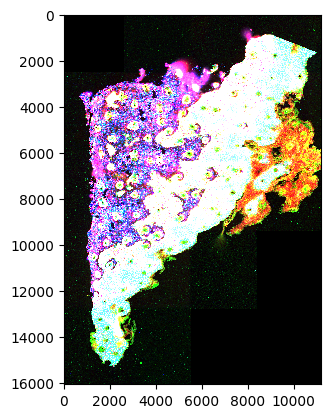

creating new log file
2026-05-09 11:20:41,000 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-09 11:20:41,005 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-09 11:20:41,506 [INFO] ** TORCH CUDA version installed and working. **
2026-05-09 11:20:41,507 [INFO] ** TORCH CUDA version installed and working. **
2026-05-09 11:20:41,507 [INFO] >>>> using GPU (CUDA)
2026-05-09 11:20:43,983 [INFO] >>>> loading model /content/drive/MyDrive/Cellpose Stuff/EF_Models + Losses/EnFace_MouseSkin_V5
initial segmentation complete
Features extracted from geojson file
Cells contained in region removed from initial mask
Removed: 5954 cells
2026-05-09 12:38:56,031 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..12683].


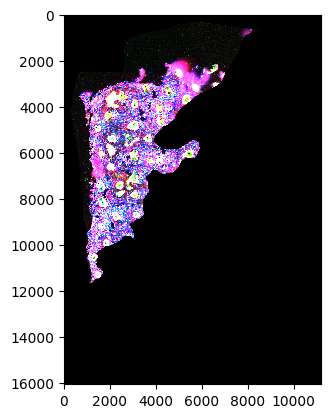

2026-05-09 12:39:00,385 [INFO] ** TORCH CUDA version installed and working. **
2026-05-09 12:39:00,386 [INFO] >>>> using GPU (CUDA)
2026-05-09 12:39:02,800 [INFO] >>>> loading model /content/drive/MyDrive/Cellpose Stuff/Cross-Section Models + Losses/Mouse_Ear_Skin_V8
Done...hopefully


In [5]:
import cellpose

model1 = "/content/drive/MyDrive/Cellpose Stuff/EF_Models + Losses/EnFace_MouseSkin_V5"
model2 = "/content/drive/MyDrive/Cellpose Stuff/Cross-Section Models + Losses/Mouse_Ear_Skin_V8"
image = "/content/drive/MyDrive/Cellpose Stuff/Registered Images/D10_M2_EnFace1/xen_all.tiff"
region_to_resegment = "/content/drive/MyDrive/Cellpose Stuff/Registered Images/D10_M2_EnFace1/dermis.geojson"
output_path = "/content/drive/MyDrive/Cellpose Stuff/Registered Images/D10_M2_EnFace1/xen_all_masks.tif"



segment_with_two_models(model1, model2, image, region_to_resegment, output_path)
print("Done...hopefully")